# Info

Author: Xiaoqian Sun </br>
Created: 06/12/2025 </br>
Function: load the best trained baseline models, predict on basleine, and get confidence level saved

In [19]:
import os
import math
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
from Functions import *
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import spearmanr
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.patches import Patch

from sklearn.metrics import confusion_matrix


from Functions import *

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

work_path = os.getcwd()
root_path = r'/Users/xiaoqiansun/Desktop/InferConnectivity'

result_path = os.path.join(work_path, 'Result')
allRuns_path = os.path.join(result_path, 'all200Runs_baseline')

resultAnalysis_path = os.path.join(work_path, 'resultAnalysis')
analysis_path = os.path.join(work_path, 'resultAnalysis', 'FMM_indi'); os.makedirs(analysis_path, exist_ok=True)


dataloader_path = os.path.join(work_path, 'dataloader')
info_df =  pd.read_csv(os.path.join(dataloader_path, 'binInfo.csv')).iloc[:, 1:]
input_dim = int(info_df['n_bins'].dropna().values[0]); timebins = info_df['t']

cmap='coolwarm'; cm_cmap='PuBu'; mC='firebrick'; bC='steelblue'; ccgColor='lightslategrey'
baseline_types = ['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40', 'allBaselines']
self_perbs = ['EI', 'EI', 'EI', 'g', 'g', 'BP',  'mu', 'mu', 'tau', 'tau']

# indicators_exc = ['peak_halfMax_width', 'peak_lag', 'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']
indicators_exc = ['peak_height', 'peak_lag', 'peak_halfMax_width', 'peak_to_noise', 'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']
indicators_inh = ['dip_depth', 'dip_lag', 'dip_halfMax_width', 'dip_to_noise', 'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']


colors = ['#ffe0b2', '#e0f7fa', '#e1bee7', '#c8e6c9', '#fff9c4']
sections = {"μ (OU mean)": [0, 15], "τ (OU tau)": [16, 25],  
            "Bursting (BP)": [26, 31], "E/I Ratio (ER)": [32, 38], "Synaptic Weights (g)": [39, 47]}



# Model Order Overall
- inh / exc
- primarily rank by harmonicMean of own perturbation accu & other perturbation accu
- if tie:
    - 1st rank by its own perturbation accu
    - 2nd rank by all other perturbation accu

In [26]:
B = 2000                          # bootstrap trials
rng = np.random.default_rng(42)   # reproducible

model_performance = []
for bIdx in range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]; self_per = self_perbs[bIdx]
    
    pred_indi_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:][['connLabel', 'predLabel', 'sample', 'test' ]]
    pred_indi_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:][['connLabel', 'predLabel', 'sample', 'test' ]]
    pred_indi_exc['hit'] = (pred_indi_exc['connLabel'] == pred_indi_exc['predLabel']).astype(int)
    pred_indi_inh['hit'] = (pred_indi_inh['connLabel'] == pred_indi_inh['predLabel']).astype(int)

    pred_indi = pd.concat([pred_indi_exc, pred_indi_inh], ignore_index=True)

    # both -------------------------------------------------------------------------------------
    # perturbation self/others
    pred_indi_self = pred_indi[pred_indi['test'].str.startswith(self_per)]
    pred_indi_other = pred_indi[~pred_indi['test'].str.startswith(self_per)]
    n_self, n_other = len(pred_indi_self), len(pred_indi_other)

    # rate / harmonic mean
    selfPerb_rate = pred_indi_self['hit'].mean() if n_self  > 0 else np.nan
    otherPerb_rate = pred_indi_other['hit'].mean() if n_other > 0 else np.nan
    if np.isfinite(selfPerb_rate) and np.isfinite(otherPerb_rate) and (selfPerb_rate + otherPerb_rate) > 0:
        hmean = 2 * selfPerb_rate * otherPerb_rate / (selfPerb_rate + otherPerb_rate)
        
        w_self, w_other = n_self / (n_self + n_other), n_other / (n_self + n_other)
        weighted_hmean = 2 * (w_self * selfPerb_rate) * (w_other * otherPerb_rate) / (w_self * selfPerb_rate + w_other * otherPerb_rate)

    else:
        hmean = np.nan

    # bootstrap 95% CI for harmonic mean (binomial resampling)
    if np.isfinite(selfPerb_rate) and np.isfinite(otherPerb_rate) and n_self > 0 and n_other > 0:
        hs = rng.binomial(n_self,  selfPerb_rate,  size=B) / n_self
        ho = rng.binomial(n_other, otherPerb_rate, size=B) / n_other
        h_boot = 2 * hs * ho / (hs + ho + 1e-12)
        h_ci_low, h_ci_high = np.percentile(h_boot, [2.5, 97.5])
    else:
        h_ci_low, h_ci_high = np.nan, np.nan


    # exc -------------------------------------------------------------------------------------
    pred_indi_exc_self = pred_indi_exc[pred_indi_exc['test'].str.startswith(self_per)]
    pred_indi_exc_other = pred_indi_exc[~pred_indi_exc['test'].str.startswith(self_per)]
    n_self_exc, n_other_exc = len(pred_indi_exc_self), len(pred_indi_exc_other)

    # rate / harmonic mean
    selfPerb_rate_exc = pred_indi_exc_self['hit'].mean() if n_self_exc  > 0 else np.nan
    otherPerb_rate_exc = pred_indi_exc_other['hit'].mean() if n_other_exc > 0 else np.nan
    if np.isfinite(selfPerb_rate_exc) and np.isfinite(otherPerb_rate_exc) and (selfPerb_rate_exc + otherPerb_rate_exc) > 0:
        hmean_exc = 2 * selfPerb_rate_exc * otherPerb_rate_exc / (selfPerb_rate_exc + otherPerb_rate_exc)
    else:
        hmean_exc = np.nan

    # bootstrap 95% CI for harmonic mean (binomial resampling)
    if np.isfinite(selfPerb_rate_exc) and np.isfinite(otherPerb_rate_exc) and n_self_exc > 0 and n_other_exc > 0:
        hs = rng.binomial(n_self_exc,  selfPerb_rate_exc,  size=B) / n_self_exc
        ho = rng.binomial(n_other_exc, otherPerb_rate_exc, size=B) / n_other_exc
        h_boot_exc = 2 * hs * ho / (hs + ho + 1e-12)
        h_ci_low_exc, h_ci_high_exc = np.percentile(h_boot_exc, [2.5, 97.5])
    else:
        h_ci_low_exc, h_ci_high_exc = np.nan, np.nan



    # inh -------------------------------------------------------------------------------------
    pred_indi_inh_self = pred_indi_inh[pred_indi_inh['test'].str.startswith(self_per)]
    pred_indi_inh_other = pred_indi_inh[~pred_indi_inh['test'].str.startswith(self_per)]
    n_self_inh, n_other_inh = len(pred_indi_inh_self), len(pred_indi_inh_other)

    # rate / harmonic mean
    selfPerb_rate_inh = pred_indi_inh_self['hit'].mean() if n_self_inh  > 0 else np.nan
    otherPerb_rate_inh = pred_indi_inh_other['hit'].mean() if n_other_inh > 0 else np.nan
    if np.isfinite(selfPerb_rate_inh) and np.isfinite(otherPerb_rate_inh) and (selfPerb_rate_inh + otherPerb_rate_inh) > 0:
        hmean_inh = 2 * selfPerb_rate_inh * otherPerb_rate_inh / (selfPerb_rate_inh + otherPerb_rate_inh)
    else:
        hmean_inh = np.nan

    # bootstrap 95% CI for harmonic mean (binomial resampling)
    if np.isfinite(selfPerb_rate_inh) and np.isfinite(otherPerb_rate_inh) and n_self_inh > 0 and n_other_inh > 0:
        hs = rng.binomial(n_self_inh,  selfPerb_rate_inh,  size=B) / n_self_inh
        ho = rng.binomial(n_other_inh, otherPerb_rate_inh, size=B) / n_other_inh
        h_boot_inh = 2 * hs * ho / (hs + ho + 1e-12)
        h_ci_low_inh, h_ci_high_inh = np.percentile(h_boot_inh, [2.5, 97.5])
    else:
        h_ci_low_inh, h_ci_high_inh = np.nan, np.nan

    

    # add
    model_performance.append([bsType, 
                    selfPerb_rate, otherPerb_rate, hmean, weighted_hmean, n_self, n_other, h_ci_low, h_ci_high,
                    selfPerb_rate_exc, otherPerb_rate_exc, hmean_exc, n_self_exc, n_other_exc, h_ci_low_exc, h_ci_high_exc,
                    selfPerb_rate_inh, otherPerb_rate_inh, hmean_inh, n_self_inh, n_other_inh, h_ci_low_inh, h_ci_high_inh])

model_performance_df = pd.DataFrame(model_performance, 
                                    columns=['baseline', 
    'selfPerb_hitRate', 'otherPerb_hitRate', 'harmonicMean', 'weightedHarmonicMean', 'n_self', 'n_other', 'harmonicMean_CI_low', 'harmonicMean_CI_high',
    'selfPerb_hitRate_exc', 'otherPerb_hitRate_exc', 'harmonicMean_exc', 'n_self_exc', 'n_other_exc', 'harmonicMean_CI_low_exc', 'harmonicMean_CI_high_exc',
    'selfPerb_hitRate_inh', 'otherPerb_hitRate_inh', 'harmonicMean_inh', 'n_self_inh', 'n_other_inh', 'harmonicMean_CI_low_inh', 'harmonicMean_CI_high_inh'])
# sort by group, then selfPerb desc, then otherPerb desc
model_performance_df = model_performance_df.sort_values(['harmonicMean', 'selfPerb_hitRate',  'otherPerb_hitRate', 'baseline'],ascending=[False, False, False, True], na_position='last').set_index('baseline')
model_performance_df.to_csv(os.path.join(analysis_path, 'connCNN_benchmarkingRank.csv'))
model_performance_df

,selfPerb_hitRate,otherPerb_hitRate,harmonicMean,weightedHarmonicMean,n_self,n_other,harmonicMean_CI_low,harmonicMean_CI_high,selfPerb_hitRate_exc,otherPerb_hitRate_exc,...,n_other_exc,harmonicMean_CI_low_exc,harmonicMean_CI_high_exc,selfPerb_hitRate_inh,otherPerb_hitRate_inh,harmonicMean_inh,n_self_inh,n_other_inh,harmonicMean_CI_low_inh,harmonicMean_CI_high_inh
baseline,,,,,,,,,,,,,,,,,,,,,
mu180,0.954688,0.997814,0.975775,0.370697,640,1830,0.966974,0.983871,1.000000,0.995996,...,999,0.995980,0.999499,0.909375,1.000000,0.952537,320,831,0.933333,0.969404
BP0.5,1.000000,0.756054,0.861083,0.170116,240,2230,0.849923,0.872314,1.000000,0.696414,...,1199,0.802796,0.838178,1.000000,0.825412,0.904357,120,1031,0.890802,0.917585
tau5,1.000000,0.507246,0.673077,0.234539,400,2070,0.654971,0.691943,1.000000,0.481680,...,1119,0.623616,0.676523,1.000000,0.537329,0.699042,200,951,0.670860,0.725201
tau40,1.000000,0.497101,0.664085,0.233226,400,2070,0.644845,0.683206,1.000000,0.480786,...,1119,0.622748,0.676523,1.000000,0.516299,0.680999,200,951,0.652975,0.707880
g1.5,1.000000,0.463256,0.633185,0.210697,360,2150,0.613351,0.653304,1.000000,0.420190,...,1159,0.562904,0.619416,1.000000,0.513623,0.678667,180,991,0.651701,0.705421
mu165,0.703125,0.559016,0.622844,0.253057,640,1830,0.604089,0.643707,0.762500,0.493493,...,999,0.571602,0.626541,0.643750,0.637786,0.640754,320,831,0.607659,0.671597
g0.5,0.444444,0.841872,0.581762,0.122429,360,2030,0.536268,0.626818,0.444444,0.799644,...,1123,0.506083,0.630147,0.444444,0.894157,0.593759,180,907,0.526013,0.654328
E5,0.428571,0.682635,0.526559,0.177812,560,1670,0.494538,0.557318,0.285714,0.760479,...,835,0.363722,0.463203,0.642857,0.604790,0.623243,224,835,0.589046,0.656589
E3,0.285714,1.000000,0.444444,0.133058,560,1630,0.397711,0.488529,0.166667,1.000000,...,490,0.226913,0.344828,0.464286,1.000000,0.634146,224,1140,0.568690,0.693878


In [25]:
model_performance_df = pd.read_csv(os.path.join(analysis_path, 'connCNN_benchmarkingRank.csv'), index_col=0)


model_performance_df = model_performance_df.sort_values(['harmonicMean', 'selfPerb_hitRate',  'otherPerb_hitRate', 'baseline'],ascending=[False, False, False, True], na_position='last')
model_order = model_performance_df.index.values; print('all-', model_order)
#all- ['mu180' 'BP0.5' 'g1.5' 'g0.5' 'tau5' 'tau40' 'E5' 'E3' 'E8' 'mu165']


model_performance_df_exc = model_performance_df.sort_values(['harmonicMean_exc', 'selfPerb_hitRate_exc',  'otherPerb_hitRate_exc', 'baseline'],ascending=[False, False, False, True], na_position='last')
model_order_exc = model_performance_df_exc.index.values; print('exc-', model_order_exc)
# exc- ['mu180' 'BP0.5' 'g1.5' 'g0.5' 'tau5' 'tau40' 'E8' 'mu165' 'E5' 'E3']

model_performance_df_inh = model_performance_df.sort_values(['harmonicMean_inh', 'selfPerb_hitRate_inh',  'otherPerb_hitRate_inh', 'baseline'],ascending=[False, False, False, True], na_position='last')
model_order_inh = model_performance_df_inh.index.values; print('inh-', model_order_inh)
# inh- ['mu180' 'BP0.5' 'g1.5' 'E3' 'E5' 'g0.5' 'tau5' 'tau40' 'mu165' 'E8']


all- ['mu180' 'BP0.5' 'tau5' 'tau40' 'g1.5' 'mu165' 'g0.5' 'E5' 'E3' 'E8']
exc- ['mu180' 'BP0.5' 'tau5' 'tau40' 'mu165' 'g1.5' 'g0.5' 'E8' 'E5' 'E3']
inh- ['mu180' 'BP0.5' 'tau5' 'tau40' 'g1.5' 'mu165' 'E3' 'E5' 'g0.5' 'E8']


# FMM VS Indicators

In [4]:
fmm_prefix = 'postBN'

In [11]:
# indis = indicators_exc 
indis = ['peak_height', 'norm_entropy_window', 'kl_divergence_window']

# exc ------------------------------------------------------------------------------------------------
for bIdx in [0,1,2]: #range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]

    # read in
    FMM_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]

    # test list associated with this baseine
    test_list = FMM_exc['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item not in ['g0.4', 'g_E80.4']]

    # to test fmm1/2 for each ccg sample
    FMM_exc['hit'] = FMM_exc.apply(lambda row: 'hit' if row['connLabel'] == row['predLabel'] else 'miss', axis=1)
    fmm_exc_test = FMM_exc[FMM_exc['test'].isin(test_list)][['test', 'hit', fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']+indis]
    fmm_exc_test = fmm_exc_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1', fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})

    fmm_exc_test_others = fmm_exc_test[~fmm_exc_test['test'].str.contains('baseline') & ~fmm_exc_test['test'].str.startswith('EI')]
    fmm_exc_test_bs = fmm_exc_test[fmm_exc_test['test'].str.contains('baseline')]
    fmm_exc_test_ei = fmm_exc_test[fmm_exc_test['test'].str.startswith('EI')]


    # plot -------
    # fig, ax = plt.subplots(2, len(indis), figsize=(5*len(indis), 6))
    fig, ax = plt.subplots(2, len(indis), figsize=(10, 4))
    for i, indi in enumerate(indis):

        if i==0 and bIdx==4:
            # all
            sns.scatterplot(data=fmm_exc_test_others, x=indi, y='fmm1', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[0, i], alpha=0.4)
            sns.scatterplot(data=fmm_exc_test_others, x=indi, y='fmm2', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[1, i], alpha=0.4)
#           # EI
            sns.scatterplot(data=fmm_exc_test_ei, x=indi, y='fmm1', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[0, i], alpha=0.8)
            sns.scatterplot(data=fmm_exc_test_ei, x=indi, y='fmm2', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[1, i], alpha=0.8)
            # baseline
            sns.scatterplot(data=fmm_exc_test_bs, x=indi, y='fmm1', ax=ax[0, i], color='k', alpha=0.4)
            sns.scatterplot(data=fmm_exc_test_bs, x=indi, y='fmm2', ax=ax[1, i], color='k', alpha=0.4)
            
            legend_elements = [Patch(facecolor='#1E88E5', label='Hit'), Patch(facecolor='#E53935', label='Miss'),
                       Patch(facecolor='#35e5b0', label='EI-Hit'), Patch(facecolor='#e535df', label='EI-Miss')] 
            ax[0, i].legend(handles=legend_elements, title='Hit/Miss', loc='lower right',)# bbox_to_anchor=(1, 0.6))
            ax[1, i].legend(handles=legend_elements, title='Hit/Miss', loc='lower right')#, bbox_to_anchor=(1, 0.6))
        
        else:
            sns.scatterplot(data=fmm_exc_test_others, x=indi, y='fmm1', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[0, i], legend=False, alpha=0.4)
            sns.scatterplot(data=fmm_exc_test_others, x=indi, y='fmm2', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[1, i], legend=False, alpha=0.4)

            sns.scatterplot(data=fmm_exc_test_ei, x=indi, y='fmm1', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[0, i], legend=False, alpha=0.8)
            sns.scatterplot(data=fmm_exc_test_ei, x=indi, y='fmm2', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[1, i], legend=False, alpha=0.8)
            
            sns.scatterplot(data=fmm_exc_test_bs, x=indi, y='fmm1', ax=ax[0, i], color='k', legend=False, alpha=0.4)
            sns.scatterplot(data=fmm_exc_test_bs, x=indi, y='fmm2', ax=ax[1, i], color='k', legend=False, alpha=0.4)
            
        
        ax[0, i].spines['right'].set_visible(False); ax[0, i].spines['top'].set_visible(False)
        ax[1, i].spines['right'].set_visible(False); ax[1, i].spines['top'].set_visible(False)
    # show y label at 1st col; show x label at 2nd row
    for r in range(2):
        for c in range(len(indis)):
            if c != 0:                     # hide Y on non-first columns
                ax[r, c].set_ylabel(''); ax[r, c].tick_params(labelleft=False)
            if r == 0:                     # hide X on top row
                ax[r, c].set_xlabel(''); ax[r, c].tick_params(labelbottom=False)
    ax[0, 0].set_ylabel('fmm1'); ax[1, 0].set_ylabel('fmm2')
    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, 'fmm_vs_indi', 'exc_'+bsType+'3.png'), pad_inches=0, dpi=300, bbox_inches="tight", transparent=True); plt.close()
    



In [10]:
# indis = indicators_inh
indis = ['dip_depth', 'norm_entropy_window', 'kl_divergence_window']


# inh ------------------------------------------------------------------------------------------------
for bIdx in [0,1,2]: #range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]

    # read in
    FMM_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]

    # test list associated with this baseine
    test_list = FMM_inh['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item not in ['g0.4', 'g_E80.4']]

    # to test fmm1/2 for each ccg sample
    FMM_inh['hit'] = FMM_inh.apply(lambda row: 'hit' if row['connLabel'] == row['predLabel'] else 'miss', axis=1)
    fmm_inh_test = FMM_inh[FMM_inh['test'].isin(test_list)][['test', 'hit', fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']+indis]
    fmm_inh_test = fmm_inh_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1', fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})

    fmm_inh_test_others = fmm_inh_test[~fmm_inh_test['test'].str.contains('baseline') & ~fmm_inh_test['test'].str.startswith('EI')]
    fmm_inh_test_bs = fmm_inh_test[fmm_inh_test['test'].str.contains('baseline')]
    fmm_inh_test_ei = fmm_inh_test[fmm_inh_test['test'].str.startswith('EI')]


    # plot -------
    fig, ax = plt.subplots(2, len(indis), figsize=(5*len(indis), 6))
    for i, indi in enumerate(indis):

        if i==0 and bIdx==5:
            # all
            sns.scatterplot(data=fmm_inh_test_others, x=indi, y='fmm1', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[0, i], alpha=0.4)
            sns.scatterplot(data=fmm_inh_test_others, x=indi, y='fmm2', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[1, i], alpha=0.4)
#           # EI
            sns.scatterplot(data=fmm_inh_test_ei, x=indi, y='fmm1', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[0, i], alpha=0.8)
            sns.scatterplot(data=fmm_inh_test_ei, x=indi, y='fmm2', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[1, i], alpha=0.8)
            # baseline
            sns.scatterplot(data=fmm_inh_test_bs, x=indi, y='fmm1', ax=ax[0, i], color='k', alpha=0.4)
            sns.scatterplot(data=fmm_inh_test_bs, x=indi, y='fmm2', ax=ax[1, i], color='k', alpha=0.4)
            
            legend_elements = [Patch(facecolor='#1E88E5', label='Hit'), Patch(facecolor='#E53935', label='Miss'),
                       Patch(facecolor='#35e5b0', label='EI-Hit'), Patch(facecolor='#e535df', label='EI-Miss')] 
            ax[0, i].legend(handles=legend_elements, title='Hit/Miss', loc='lower right',)# bbox_to_anchor=(1, 0.6))
            ax[1, i].legend(handles=legend_elements, title='Hit/Miss', loc='lower right')#, bbox_to_anchor=(1, 0.6))
        
        else:
            sns.scatterplot(data=fmm_inh_test_others, x=indi, y='fmm1', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[0, i], legend=False, alpha=0.4)
            sns.scatterplot(data=fmm_inh_test_others, x=indi, y='fmm2', hue='hit', palette={'hit': '#1E88E5', 'miss': '#E53935'}, ax=ax[1, i], legend=False, alpha=0.4)

            sns.scatterplot(data=fmm_inh_test_ei, x=indi, y='fmm1', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[0, i], legend=False, alpha=0.8)
            sns.scatterplot(data=fmm_inh_test_ei, x=indi, y='fmm2', hue='hit', palette={'hit': '#35e5b0', 'miss': '#e535df'}, ax=ax[1, i], legend=False, alpha=0.8)
            
            sns.scatterplot(data=fmm_inh_test_bs, x=indi, y='fmm1', ax=ax[0, i], color='k', legend=False, alpha=0.4)
            sns.scatterplot(data=fmm_inh_test_bs, x=indi, y='fmm2', ax=ax[1, i], color='k', legend=False, alpha=0.4)
        
        ax[0, i].spines['right'].set_visible(False); ax[0, i].spines['top'].set_visible(False)
        ax[1, i].spines['right'].set_visible(False); ax[1, i].spines['top'].set_visible(False)
    # show y label at 1st col; show x label at 2nd row
    for r in range(2):
        for c in range(len(indis)):
            if c != 0:                     # hide Y on non-first columns
                ax[r, c].set_ylabel(''); ax[r, c].tick_params(labelleft=False)
            if r == 0:                     # hide X on top row
                ax[r, c].set_xlabel(''); ax[r, c].tick_params(labelbottom=False)
    ax[0, 0].set_ylabel('fmm1'); ax[1, 0].set_ylabel('fmm2')
    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, 'fmm_vs_indi', 'inh_'+bsType+'3.png'), pad_inches=0, dpi=300, bbox_inches="tight", transparent=True); plt.close()


# PostBN FMM Bi-Polar Visualization

In [12]:
fmm_prefix = 'postBN'
cmap = plt.get_cmap('coolwarm_r')

### all perturbations per baseline

In [14]:
# exc ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]

    FMM_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]
    FMM_exc['hit'] = (FMM_exc['connLabel']==FMM_exc['predLabel']).astype(int)
    
    test_list = FMM_exc['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item not in ['g0.4', 'g_E80.4']]


    R, C = 6, 8; fig, ax = plt.subplots(R, C, figsize=(20, 16)); ax = ax.flatten()
    for axIdx in range(R*C):
        try:
            test = test_list[axIdx]
            FMM_exc_test = FMM_exc[FMM_exc['test']==test]
            correct_ratio = FMM_exc_test['hit'].sum() / len(FMM_exc_test)
            sub_title = test + ' Accu=' + str(round(correct_ratio*100, 2))
            title_color = cmap(correct_ratio)
    
            fmm_exc_test = FMM_exc[FMM_exc['test'] == test][[fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
            fmm_exc_test = fmm_exc_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1',
                                                        fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})
            fmm_exc_test_melt = fmm_exc_test.melt(var_name='FeatureMap', value_name='FMM Value')
            sns.violinplot(data=fmm_exc_test_melt, x='FeatureMap', y='FMM Value', inner='box', color='#1E88E5', linewidth=1, ax=ax[axIdx], alpha=0.6)
            ax[axIdx].set_title(sub_title, fontweight='bold', color=title_color) 
        except IndexError:
            ax[axIdx].axis('off')  # no data to plot, hide this subplot
        except Exception as e:
            print(e)
            ax[axIdx].axis('off')

    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'exc_'+bsType+'.png')); plt.close()



In [15]:
# inh ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]

    FMM_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]
    FMM_inh['hit'] = (FMM_inh['connLabel']==FMM_inh['predLabel']).astype(int)
    
    test_list = FMM_inh['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item not in ['g0.4', 'g_E80.4']]


    R, C = 6, 8; fig, ax = plt.subplots(R, C, figsize=(20, 16)); ax = ax.flatten()
    for axIdx in range(R*C):
        try:
            test = test_list[axIdx]
            FMM_inh_test = FMM_inh[FMM_inh['test']==test]
            correct_ratio = FMM_inh_test['hit'].sum() / len(FMM_inh_test)
            sub_title = test + ' Accu=' + str(round(correct_ratio*100, 2))
            title_color = cmap(correct_ratio)
    
            fmm_inh_test = FMM_inh[FMM_inh['test'] == test][[fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
            fmm_inh_test = fmm_inh_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1',
                                                        fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})
            fmm_inh_test_melt = fmm_inh_test.melt(var_name='FeatureMap', value_name='FMM Value')
            sns.violinplot(data=fmm_inh_test_melt, x='FeatureMap', y='FMM Value', inner='box', color='#1E88E5', linewidth=1, ax=ax[axIdx], alpha=0.6)
            ax[axIdx].set_title(sub_title, fontweight='bold', color=title_color) 
        except IndexError:
            ax[axIdx].axis('off')  # no data to plot, hide this subplot
        except Exception as e:
            print(e)
            ax[axIdx].axis('off')

    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'inh_'+bsType+'.png')); plt.close()



### only baselines
#### setup & legend

In [4]:
# all allBaselines at the first place
model_order_all = np.insert(model_order, 0, "allBaselines") 
model_order_all_exc = np.insert(model_order_exc, 0, "allBaselines") 
model_order_all_inh = np.insert(model_order_inh, 0, "allBaselines") 

# take a look
model_performance_df.copy().round(4).T.loc[['harmonicMean']]


baseline,mu180,BP0.5,g1.5,g0.5,tau5,tau40,E5,E3,E8,mu165
harmonicMean,0.9758,0.8611,0.6332,0.5818,0.5597,0.5367,0.5266,0.4444,0.4369,0.3585


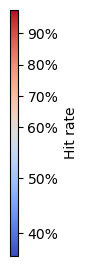

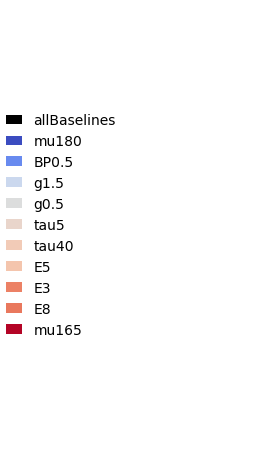

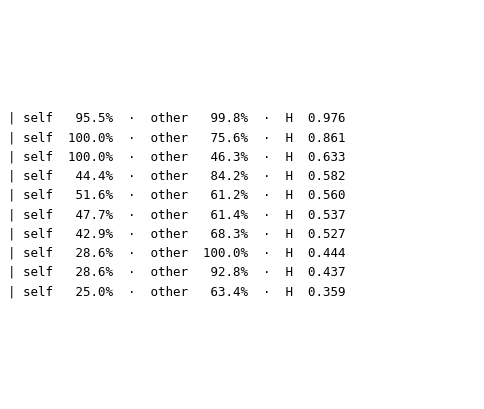

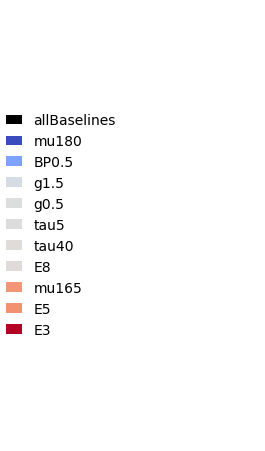

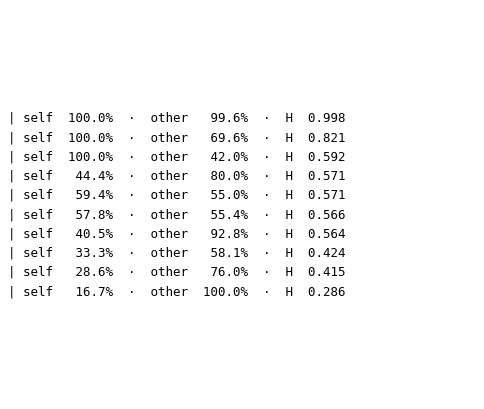

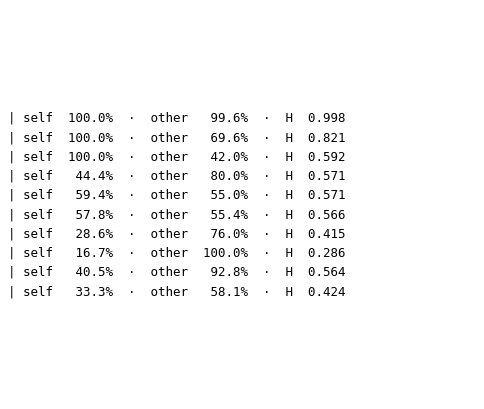

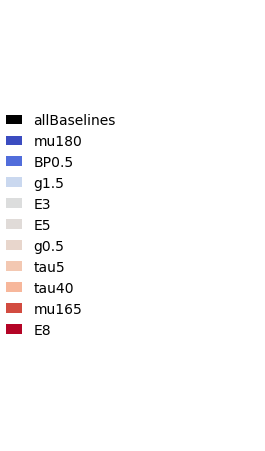

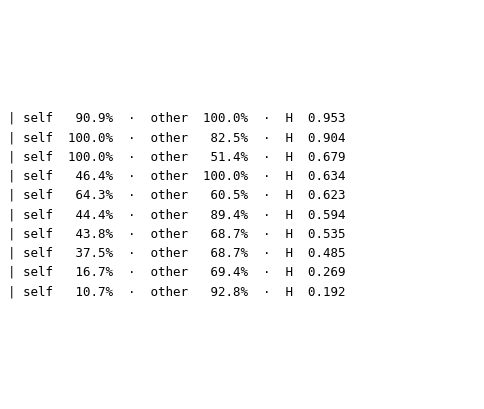

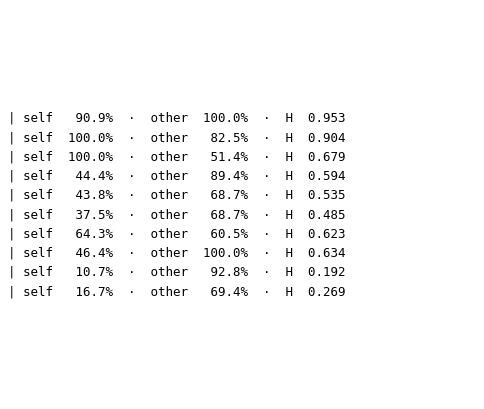

In [5]:
# standalone colorbar for the above plot ----------------------
model_hMean = model_performance_df.copy().round(4)['harmonicMean']
thresh = model_hMean.iloc[3]
norm  = mcolors.TwoSlopeNorm(vcenter=thresh, vmin=model_hMean.min(), vmax=model_hMean.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig_cb, ax_cb = plt.subplots(figsize=(0.1, 3.2))  # vertical, skinny
cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical')
cbar.set_label('Hit rate'); cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
fig_cb.tight_layout()
# fig_cb.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_colorbar.png'), dpi=300, bbox_inches="tight", transparent=True); plt.close(fig_cb)


# standalone legend All model_order===================================================================
# assign each baseline model a color
model_hMean = model_performance_df.copy().round(4)['harmonicMean']
thresh = model_hMean.iloc[3]
norm  = mcolors.TwoSlopeNorm(vcenter=thresh, vmin=model_hMean.min(), vmax=model_hMean.max())
cmap  = plt.get_cmap('coolwarm_r')  # reversed so high hMean -> blue
palette = {b: cmap(norm(model_hMean.loc[b])) for b in model_order};palette['allBaselines'] = 'black' 
# color + model -------------------------------------------------------
handles_names = [Patch(facecolor=palette[b], label=f"{b}") for b in model_order_all]
fig = plt.figure(figsize=(2.6, 0.42*len(model_order_all)))
fig.legend(handles=handles_names, loc='center left', frameon=False, handlelength=1.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_colorModel.png'), pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)
# rates ---------------------------------------------------------------
mp = model_performance_df.copy()
handles_rates = [Line2D([], [], linestyle='None', marker=None,
                        label=(f"| self {pct(mp.at[b,'selfPerb_hitRate'])}  ·  "
                               f"other {pct(mp.at[b,'otherPerb_hitRate'])}  ·  "
                               f"H {mp.at[b,'harmonicMean']:>6.3f}")) for b in model_order]
fig = plt.figure(figsize=(4.8, 0.42*len(model_order)))
fig.legend(handles=handles_rates, loc='center left', frameon=False, prop={'family': 'monospace', 'size': 9}, handlelength=0.0, handletextpad=0.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_rates.png'),pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)


# standalone legend model_order_exc===================================================================
# assign each baseline model a color
model_hMean = model_performance_df_exc.copy().round(4)['harmonicMean_exc']
thresh = model_hMean.iloc[3]
norm  = mcolors.TwoSlopeNorm(vcenter=thresh, vmin=model_hMean.min(), vmax=model_hMean.max())
cmap  = plt.get_cmap('coolwarm_r')  # reversed so high hMean -> blue
palette_exc = {b: cmap(norm(model_hMean.loc[b])) for b in model_order_exc}; palette_exc['allBaselines'] = 'black' 

# color + model -------------------------------------------------------
handles_names = [Patch(facecolor=palette_exc[b], label=f"{b}") for b in model_order_all_exc]
fig = plt.figure(figsize=(2.6, 0.42*len(model_order_all_exc)))
fig.legend(handles=handles_names, loc='center left', frameon=False, handlelength=1.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_colorModel_exc.png'), pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)
# rates ---------------------------------------------------------------
mp = model_performance_df_exc.copy()
handles_rates = [Line2D([], [], linestyle='None', marker=None,
                        label=(f"| self {pct(mp.at[b,'selfPerb_hitRate_exc'])}  ·  "
                               f"other {pct(mp.at[b,'otherPerb_hitRate_exc'])}  ·  "
                               f"H {mp.at[b,'harmonicMean_exc']:>6.3f}")) for b in model_order_exc]
fig = plt.figure(figsize=(4.8, 0.42*len(model_order_exc)))
fig.legend(handles=handles_rates, loc='center left', frameon=False, prop={'family': 'monospace', 'size': 9}, handlelength=0.0, handletextpad=0.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_rates_exc.png'),pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)
# rates, exc numbers, but using overall model_order---------------------
mp = model_performance_df.copy()
handles_rates = [Line2D([], [], linestyle='None', marker=None,
                        label=(f"| self {pct(mp.at[b,'selfPerb_hitRate_exc'])}  ·  "
                               f"other {pct(mp.at[b,'otherPerb_hitRate_exc'])}  ·  "
                               f"H {mp.at[b,'harmonicMean_exc']:>6.3f}")) for b in model_order]
fig = plt.figure(figsize=(4.8, 0.42*len(model_order)))
fig.legend(handles=handles_rates, loc='center left', frameon=False, prop={'family': 'monospace', 'size': 9}, handlelength=0.0, handletextpad=0.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_rates_exc_same.png'),pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)



# standalone legend All model_order_inh===================================================================
model_hMean = model_performance_df_inh.copy().round(4)['harmonicMean_inh']
thresh = model_hMean.iloc[3]
norm  = mcolors.TwoSlopeNorm(vcenter=thresh, vmin=model_hMean.min(), vmax=model_hMean.max())
cmap  = plt.get_cmap('coolwarm_r')  # reversed so high hMean -> blue
palette_inh = {b: cmap(norm(model_hMean.loc[b])) for b in model_order_inh}; palette_inh['allBaselines'] = 'black' 
# color + model -------------------------------------------------------
handles_names = [Patch(facecolor=palette_inh[b], label=f"{b}") for b in model_order_all_inh]
fig = plt.figure(figsize=(2.6, 0.42*len(model_order_all_inh)))
fig.legend(handles=handles_names, loc='center left', frameon=False, handlelength=1.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_colorModel_inh.png'), pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)
# rates ---------------------------------------------------------------
mp = model_performance_df_inh.copy()
handles_rates = [Line2D([], [], linestyle='None', marker=None,
                        label=(f"| self {pct(mp.at[b,'selfPerb_hitRate_inh'])}  ·  "
                               f"other {pct(mp.at[b,'otherPerb_hitRate_inh'])}  ·  "
                               f"H {mp.at[b,'harmonicMean_inh']:>6.3f}")) for b in model_order_inh]
fig = plt.figure(figsize=(4.8, 0.42*len(model_order_inh)))
fig.legend(handles=handles_rates, loc='center left', frameon=False, prop={'family': 'monospace', 'size': 9}, handlelength=0.0, handletextpad=0.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_rates_inh.png'),pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)
# rates, inh numbers, but using overall model_order ---------------------
mp = model_performance_df.copy()
handles_rates = [Line2D([], [], linestyle='None', marker=None,
                        label=(f"| self {pct(mp.at[b,'selfPerb_hitRate_inh'])}  ·  "
                               f"other {pct(mp.at[b,'otherPerb_hitRate_inh'])}  ·  "
                               f"H {mp.at[b,'harmonicMean_inh']:>6.3f}")) for b in model_order]
fig = plt.figure(figsize=(4.8, 0.42*len(model_order)))
fig.legend(handles=handles_rates, loc='center left', frameon=False, prop={'family': 'monospace', 'size': 9}, handlelength=0.0, handletextpad=0.2, borderaxespad=0.0)
plt.axis('off'); fig.tight_layout()
# fig.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'a_rates_inh_same.png'),pad_inches=0, dpi=300, bbox_inches='tight', transparent=True); plt.close(fig)


#### all

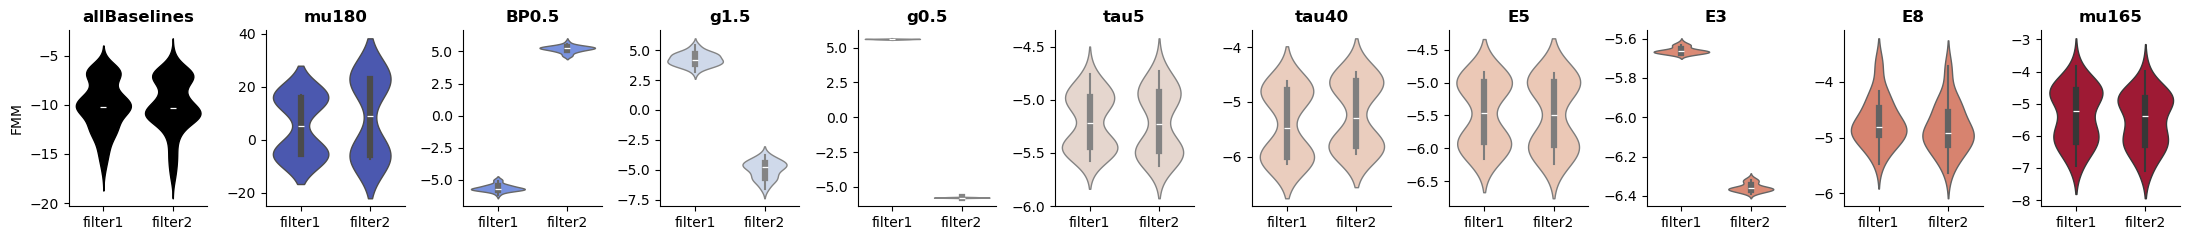

In [324]:
# both ------------------------------------------------------------------------------------------------
exc_max, exc_min, inh_max, inh_min = [], [], [], []

# model_order_list = model_order; prefix=''
model_order_list = model_order_all; prefix='_all'
fig, ax = plt.subplots(1, len(model_order_list), figsize=(2*len(model_order_list), 2.5)); ax = ax.flatten()
for bIdx in range(len(model_order_list)):
    
    bsType = model_order_list[bIdx]; bs_test = 'baseline_'+bsType if bsType!='allBaselines' else 'baseline_all'

    FMM_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]
    FMM_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]
    
    FMM_exc_test = FMM_exc[FMM_exc['test']==bs_test]
    fmm_exc_test = FMM_exc_test[[fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_exc_test = fmm_exc_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'filter1', fmm_prefix+'_conn_conv2_fm1_mean': 'filter2'})

    FMM_inh_test = FMM_inh[FMM_inh['test']==bs_test]
    fmm_inh_test = FMM_inh_test[[fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_inh_test = fmm_inh_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'filter1', fmm_prefix+'_conn_conv2_fm1_mean': 'filter2'})


    fmm_test = pd.concat([fmm_exc_test, fmm_inh_test], ignore_index=True)
    exc_max.append(fmm_exc_test.max().max()); exc_min.append(fmm_exc_test.min().min())
    inh_max.append(fmm_inh_test.max().max()); inh_min.append(fmm_inh_test.min().min())
    fmm_test_melt = fmm_test.melt(var_name='FeatureMap', value_name='FMM Value')

    # plot violin
    base_color = palette.get(bsType, '#9E9E9E')    
    color_rgba = mcolors.to_rgba(base_color, alpha=0.6)
    sns.violinplot(data=fmm_test_melt, x='FeatureMap', y='FMM Value', inner='box', color=color_rgba, linewidth=1, ax=ax[bIdx])

    if bIdx==0:
        ax[bIdx].set(ylabel='FMM', xlabel=None);
    else:
        ax[bIdx].set(ylabel=None, xlabel=None); 
    ax[bIdx].spines['right'].set_visible(False); ax[bIdx].spines['top'].set_visible(False)
    ax[bIdx].set_title(bsType, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'baselines'+prefix+'.png'), pad_inches=0, dpi=300, bbox_inches="tight", transparent=True); plt.show()


In [247]:
excMax = max(exc_max); excMin = min(exc_min); print(excMax, excMin); excMax, excMin = 24, -8
inhMax = max(inh_max); inhMin = min(inh_min); print(inhMax, inhMin); inhMax, inhMin = 17, -8


23.275033950805664 -7.102208614349365
16.818214416503906 -7.231750011444092


#### exc

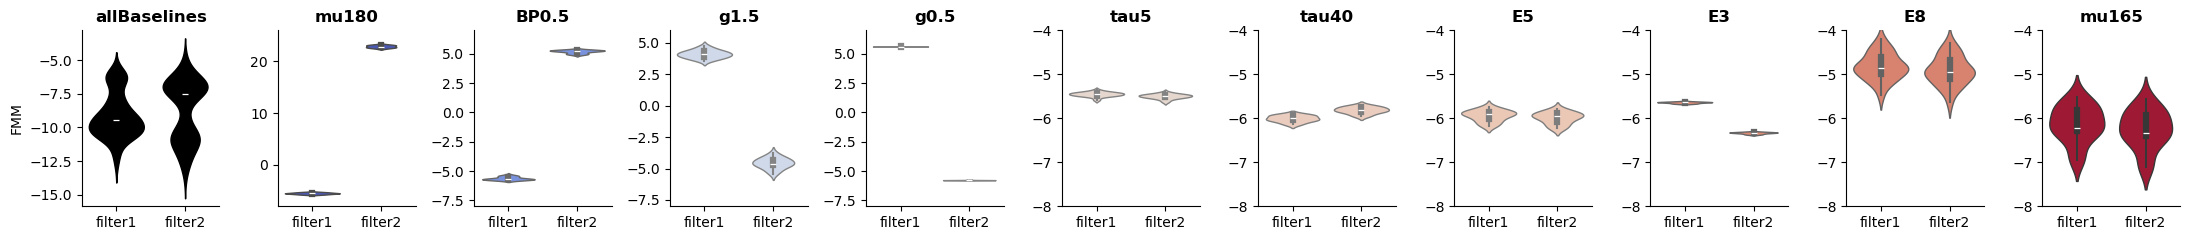

In [330]:
# exc ------------------------------------------------------------------------------------------------
# model_order_list = model_order; cp = palette; prefix='_same'
model_order_list = model_order_all; cp = palette; prefix='_allSame'
# model_order_list = model_order_exc; cp = palette_exc; prefix=''

fig, ax = plt.subplots(1, len(model_order_list), figsize=(2*len(model_order_list), 2.5)); ax = ax.flatten()
for bIdx in range(len(model_order_list)):
    
    bsType = model_order_list[bIdx]; bs_test = 'baseline_'+bsType if bsType!='allBaselines' else 'baseline_all'
    
    FMM_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]
    
    FMM_exc_test = FMM_exc[FMM_exc['test']==bs_test]
    fmm_exc_test = FMM_exc_test[[fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_exc_test = fmm_exc_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'filter1', fmm_prefix+'_conn_conv2_fm1_mean': 'filter2'})
    fmm_exc_test_melt = fmm_exc_test.melt(var_name='FeatureMap', value_name='FMM Value')

    # plot violin
    base_color = cp.get(bsType, '#9E9E9E')    
    color_rgba = mcolors.to_rgba(base_color, alpha=0.6)
    sns.violinplot(data=fmm_exc_test_melt, x='FeatureMap', y='FMM Value', inner='box', color=color_rgba, linewidth=1, ax=ax[bIdx])

    if bIdx==0:
        ax[bIdx].set(ylabel='FMM', xlabel=None);
    else:
        ax[bIdx].set(ylabel=None, xlabel=None); 
    ax[bIdx].spines['right'].set_visible(False); ax[bIdx].spines['top'].set_visible(False)
    ax[bIdx].set_title(bsType, fontsize=12, fontweight='bold'); 
    if bsType in ['tau5', 'tau40', 'E5', 'E3', 'E8', 'mu165']:
        ax[bIdx].set_ylim(-8, -4)
    elif bs_test != 'baseline_all':
        _, ymax = ax[bIdx].get_ylim(); ax[bIdx].set_ylim(-8, math.ceil(ymax))

plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'baselines_exc'+prefix+'.png'), pad_inches=0, dpi=300, bbox_inches="tight", transparent=True); plt.show()


#### inh

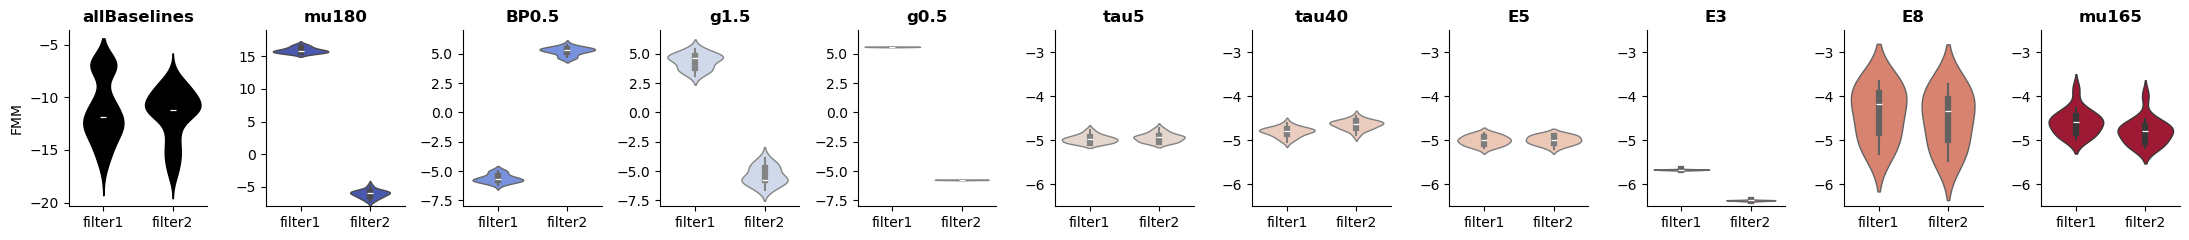

In [331]:
# inh ------------------------------------------------------------------------------------------------
# model_order_list = model_order; cp = palette; prefix='_same'
model_order_list = model_order_all; cp = palette; prefix='_allSame'
# model_order_list = model_order_inh; cp = palette_inh; prefix=''
fig, ax = plt.subplots(1, len(model_order_list), figsize=(2*len(model_order_list), 2.5)); ax = ax.flatten()
for bIdx in range(len(model_order_list)):
    
    bsType = model_order_list[bIdx]; bs_test = 'baseline_'+bsType if bsType!='allBaselines' else 'baseline_all'

    FMM_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]
    FMM_inh['hit'] = (FMM_inh['connLabel']==FMM_inh['predLabel']).astype(int)
    
    FMM_inh_test = FMM_inh[FMM_inh['test']==bs_test]
    correct_ratio = FMM_inh_test['hit'].sum() / len(FMM_inh_test)
    fmm_inh_test = FMM_inh_test[[fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_inh_test = fmm_inh_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'filter1', fmm_prefix+'_conn_conv2_fm1_mean': 'filter2'})
    fmm_inh_test_melt = fmm_inh_test.melt(var_name='FeatureMap', value_name='FMM Value')

    # plot violin
    base_color = cp.get(bsType, '#9E9E9E')    
    color_rgba = mcolors.to_rgba(base_color, alpha=0.6)
    sns.violinplot(data=fmm_inh_test_melt, x='FeatureMap', y='FMM Value', inner='box', color=color_rgba, linewidth=1, ax=ax[bIdx])

    if bIdx==0:
        ax[bIdx].set(ylabel='FMM', xlabel=None);
    else:
        ax[bIdx].set(ylabel=None, xlabel=None); 
    ax[bIdx].spines['right'].set_visible(False); ax[bIdx].spines['top'].set_visible(False)
    ax[bIdx].set_title(bsType, fontsize=12, fontweight='bold')
    if bsType in ['tau5', 'tau40', 'E5', 'E3', 'E8', 'mu165']:
        ax[bIdx].set_ylim(-6.5, -2.5)
    elif bs_test != 'baseline_all':
        _, ymax = ax[bIdx].get_ylim(); ax[bIdx].set_ylim(-8, math.ceil(ymax))


plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_dist', 'baselines_inh'+prefix+'.png'), pad_inches=0, dpi=300, bbox_inches="tight", transparent=True); plt.show()


### basleine + EI

In [5]:
fmm_prefix = 'postBN'
cmap = plt.get_cmap('coolwarm_r')

import re
def clean_test_value(val):
    # Remove patterns like _g0.5 or _BP0.5
    return re.sub(r'_g0\.5|_BP0\.5|_g1\.5|_mu165|_mu180|_tau5|tau40|', '', val)

print(baseline_types)

['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40', 'allBaselines']


In [13]:
# exc ------------------------------------------------------------------------------------------------
for bIdx in [0, 1, 2]: #range(len(baseline_types)-1):

    bsType = baseline_types[bIdx]

    # read in
    FMM_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]
    FMM_exc['hit'] = (FMM_exc['connLabel']==FMM_exc['predLabel']).astype(int)


    # test list associated with this baseine
    test_list = FMM_exc['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item.startswith('EI') or item.startswith('baseline')]

    # to get label color
    colors = []
    for test in test_list:
        FMM_exc_test = FMM_exc[FMM_exc['test']==test]
        correct_ratio = FMM_exc_test['hit'].sum() / len(FMM_exc_test)
        colors.append(cmap(correct_ratio))

    
    
    # to test fmm1/2 for each ccg sample
    fmm_exc_test = FMM_exc[FMM_exc['test'].isin(test_list)][['test', fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_exc_test['test'] = fmm_exc_test['test'].apply(clean_test_value)
    fmm_exc_test = fmm_exc_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1',
                                                fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})
    fmm_exc_test_melt = fmm_exc_test.melt(id_vars=['test'], value_vars=['fmm1', 'fmm2'], var_name='fm_type', value_name='value')
    
    # plot ----------------------------  
    plt.figure(figsize=(10, 4))
    # sns.violinplot(data=fmm_exc_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=0.8)
    sns.violinplot(data=fmm_exc_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=2, fill=False)
    sns.stripplot(data=fmm_exc_test_melt, x='test', y='value', hue='fm_type', dodge=True, jitter=True, size=2, color='grey', alpha=0.2, legend=False)

    ax = plt.gca(); xticks = ax.get_xticks()
    for ticklabel, color in zip(ax.get_xticklabels(), colors):
        ticklabel.set_color(color)
        ticklabel.set_fontweight('bold')
    for i, x in enumerate(xticks):
        if i % 2 == 0:  # shade every other group
            ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.2, zorder=-1)
    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_EI_fmm', 'exc_'+bsType+'.png')); plt.close()


In [6]:
# inh ------------------------------------------------------------------------------------------------
for bIdx in [0, 1, 2]: #range(len(baseline_types)-1):

    bsType = baseline_types[bIdx]

    # read in
    FMM_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]
    FMM_inh['hit'] = (FMM_inh['connLabel']==FMM_inh['predLabel']).astype(int)


    # test list associated with this baseine
    test_list = FMM_inh['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item.startswith('EI') or item.startswith('baseline')]

    # to get label color
    colors = []
    for test in test_list:
        FMM_inh_test = FMM_inh[FMM_inh['test']==test]
        correct_ratio = FMM_inh_test['hit'].sum() / len(FMM_inh_test)
        colors.append(cmap(correct_ratio))

    
    
    # to test fmm1/2 for each ccg sample
    fmm_inh_test = FMM_inh[FMM_inh['test'].isin(test_list)][['test', fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_inh_test['test'] = fmm_inh_test['test'].apply(clean_test_value)
    fmm_inh_test = fmm_inh_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1',
                                                fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})
    fmm_inh_test_melt = fmm_inh_test.melt(id_vars=['test'], value_vars=['fmm1', 'fmm2'], var_name='fm_type', value_name='value')
    
    # plot ----------------------------  
    plt.figure(figsize=(15, 4))
    # sns.violinplot(data=fmm_inh_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=0.8)
    sns.violinplot(data=fmm_inh_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=2, fill=False)
    sns.stripplot(data=fmm_inh_test_melt, x='test', y='value', hue='fm_type', dodge=True, jitter=True, size=2, color='grey', alpha=0.2, legend=False)

    ax = plt.gca(); xticks = ax.get_xticks()
    for ticklabel, color in zip(ax.get_xticklabels(), colors):
        ticklabel.set_color(color)
        ticklabel.set_fontweight('bold')
    for i, x in enumerate(xticks):
        if i % 2 == 0:  # shade every other group
            ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.2, zorder=-1)
    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_EI_fmm', 'inh_'+bsType+'.png')); plt.close()

    break

### baseline + g

In [21]:
# exc ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)-1):

    bsType = baseline_types[bIdx]

    # read in
    FMM_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]
    FMM_exc['hit'] = (FMM_exc['connLabel']==FMM_exc['predLabel']).astype(int)


    # test list associated with this baseine
    test_list = FMM_exc['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item.startswith('g') or item.startswith('baseline')]

    # to get label color
    colors = []
    for test in test_list:
        FMM_exc_test = FMM_exc[FMM_exc['test']==test]
        correct_ratio = FMM_exc_test['hit'].sum() / len(FMM_exc_test)
        colors.append(cmap(correct_ratio))

    
    
    # to test fmm1/2 for each ccg sample
    fmm_exc_test = FMM_exc[FMM_exc['test'].isin(test_list)][['test', fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_exc_test['test'] = fmm_exc_test['test'].apply(clean_test_value)
    fmm_exc_test = fmm_exc_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1',
                                                fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})
    fmm_exc_test_melt = fmm_exc_test.melt(id_vars=['test'], value_vars=['fmm1', 'fmm2'], var_name='fm_type', value_name='value')
    
    # plot ----------------------------  
    plt.figure(figsize=(15, 4))
    # sns.violinplot(data=fmm_exc_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=0.8)
    sns.violinplot(data=fmm_exc_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=2, fill=False)
    sns.stripplot(data=fmm_exc_test_melt, x='test', y='value', hue='fm_type', dodge=True, jitter=True, size=2, color='grey', alpha=0.2, legend=False)

    ax = plt.gca(); xticks = ax.get_xticks()
    for ticklabel, color in zip(ax.get_xticklabels(), colors):
        ticklabel.set_color(color)
    for i, x in enumerate(xticks):
        if i % 2 == 0:  # shade every other group
            ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.2, zorder=-1)
    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_g_fmm', 'exc_'+bsType+'.png')); plt.close()
    

In [22]:
# inh ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)-1):

    bsType = baseline_types[bIdx]

    # read in
    FMM_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]
    FMM_inh['hit'] = (FMM_inh['connLabel']==FMM_inh['predLabel']).astype(int)


    # test list associated with this baseine
    test_list = FMM_inh['test'].drop_duplicates().tolist()
    test_list = [item for item in test_list if item.startswith('g') or item.startswith('baseline')]

    # to get label color
    colors = []
    for test in test_list:
        FMM_inh_test = FMM_inh[FMM_inh['test']==test]
        correct_ratio = FMM_inh_test['hit'].sum() / len(FMM_inh_test)
        colors.append(cmap(correct_ratio))

    
    
    # to test fmm1/2 for each ccg sample
    fmm_inh_test = FMM_inh[FMM_inh['test'].isin(test_list)][['test', fmm_prefix+'_conn_conv2_fm0_mean', fmm_prefix+'_conn_conv2_fm1_mean']]
    fmm_inh_test['test'] = fmm_inh_test['test'].apply(clean_test_value)
    fmm_inh_test = fmm_inh_test.rename(columns={fmm_prefix+'_conn_conv2_fm0_mean': 'fmm1',
                                                fmm_prefix+'_conn_conv2_fm1_mean': 'fmm2'})
    fmm_inh_test_melt = fmm_inh_test.melt(id_vars=['test'], value_vars=['fmm1', 'fmm2'], var_name='fm_type', value_name='value')
    
    # plot ----------------------------  
    plt.figure(figsize=(15, 4))
    # sns.violinplot(data=fmm_inh_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=0.8)
    sns.violinplot(data=fmm_inh_test_melt, x='test', y='value', hue='fm_type', split=False, linewidth=2, fill=False)
    sns.stripplot(data=fmm_inh_test_melt, x='test', y='value', hue='fm_type', dodge=True, jitter=True, size=2, color='grey', alpha=0.2, legend=False)

    ax = plt.gca(); xticks = ax.get_xticks()
    for ticklabel, color in zip(ax.get_xticklabels(), colors):
        ticklabel.set_color(color)
    for i, x in enumerate(xticks):
        if i % 2 == 0:  # shade every other group
            ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.2, zorder=-1)
    plt.tight_layout(); plt.savefig(os.path.join(analysis_path, fmm_prefix+'_g_fmm', 'inh_'+bsType+'.png')); plt.close()


# Random Forest +SHAP
Indicators Predct Hit/Miss

In [6]:
# packages for RF/DT/analysis
import shap
import matplotlib
from functools import reduce
from matplotlib.patches import Patch
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

'''
indicators_exc = ['peak_height', 'peak_lag', 'peak_halfMax_width', 'peak_to_noise', 
                  'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']
indicators_inh = ['dip_depth', 'dip_lag', 'dip_halfMax_width', 'dip_to_noise', 'temporal_span', 
                  'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']
'''
print(baseline_types)

['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40', 'allBaselines']


In [7]:
mus = [150+2*i for i in range(16)]; mu_prefix = ['mu'+str(mu) for mu in mus]
taus = [5*i for i in range(1, 11)]; tau_prefix = ['tau'+str(tau) for tau in taus]
BPs = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]; BP_prefix = ['BP'+str(BP) for BP in BPs]
EIs = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]; EI_prefix  = ['EI'+str(EI) for EI in EIs]
gs = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]; gbar_prefix = ['g'+str(g) for g in gs]
perturbs_list = mu_prefix + tau_prefix + BP_prefix + EI_prefix + gbar_prefix

# background color marking perturbations
colors = ['#ffe0b2', '#e0f7fa', '#e1bee7', '#c8e6c9', '#fff9c4']
sections = {"μ (OU mean)": [0, 15], "τ (OU tau)": [16, 25],  
            "Bursting (BP)": [26, 31], "E/I Ratio (ER)": [32, 38], "Synaptic Weights (g)": [39, 47]}

# color palette
p1 = {'hit': '#1E88E5', 'miss': '#E53935'}    # Blue vs Red    (Peak Height)
p2 = {'hit': '#35e5b0', 'miss': '#e535df'}    # Green vs Pink  (Norm Entropy)
p3 = {'hit': 'grey',    'miss': '#e5ce35'}    # Grey vs Yellow (kl_divergence_window)
p4 = {'hit': '#1e2be5', 'miss': '#F4A261'}    # navy vs orange (all others)
exc_indi_palette = {'peak_height':p1, 'peak_lag':p4, 'peak_halfMax_width':p4,  'peak_to_noise':p4, 'temporal_span':p4, 
                    'entropy':    p2, 'norm_entropy':p2, 'norm_entropy_window': p2, 'kl_divergence_window':p3}

inh_indi_palette = {'dip_depth':  p1, 'dip_lag':p4, 'dip_halfMax_width':p4,  'dip_to_noise':p4, 'temporal_span':p4, 
                    'entropy':    p2, 'norm_entropy':p2, 'norm_entropy_window': p2, 'kl_divergence_window':p3}


## ! How many indis to use!

In [8]:
# indicators_exc = ['peak_height', 'peak_to_noise', 'norm_entropy', 'kl_divergence_window']
# indicators_inh = ['dip_depth', 'dip_to_noise', 'norm_entropy', 'kl_divergence_window']

indicators_exc = ['peak_height', 'peak_to_noise', 'temporal_span', 'norm_entropy', 'kl_divergence_window']
indicators_inh = ['dip_depth', 'dip_to_noise', 'temporal_span',  'norm_entropy', 'kl_divergence_window']

RF_SHAP = f'RF_SHAP_{len(indicators_exc)}' if len(indicators_exc) != 9 else 'RF_SHAP'
RF_SHAP_inh = f'RF_SHAP_inh_{len(indicators_exc)}' if len(indicators_exc) != 9 else 'RF_SHAP_inh'
print(RF_SHAP)

os.makedirs(os.path.join(analysis_path, RF_SHAP), exist_ok=True)
os.makedirs(os.path.join(analysis_path, RF_SHAP_inh), exist_ok=True)
os.makedirs(os.path.join(analysis_path, RF_SHAP, 'tables'), exist_ok=True)
os.makedirs(os.path.join(analysis_path, RF_SHAP_inh, 'tables'), exist_ok=True)

RF_SHAP_5


### Exc RF

In [9]:
# note - for allBaselines, no enough miss samples
# exc ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)):
    bsType = baseline_types[bIdx]
    pred_indi_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]
    pred_indi_exc['hit'] = (pred_indi_exc['connLabel'] == pred_indi_exc['predLabel']).astype(int)
    counts = pred_indi_exc['hit'].value_counts(); 

    if counts.get(0, 0) > 1:
        print(bsType, ':', f"0-miss-{counts.get(0, 0)} |", f"1-hit-{counts.get(1, 0)}")
        X = pred_indi_exc[indicators_exc]
        y = pred_indi_exc['hit']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
        
        # RF ------------------------------------------------------------------------------------------
        RF_Model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        RF_Model.fit(X_train, y_train); RF_yPred = RF_Model.predict(X_test)
        RF_report = pd.DataFrame(classification_report(y_test, RF_yPred, output_dict=True)).transpose().reset_index()
        RF_FI = pd.DataFrame([X.columns, RF_Model.feature_importances_], index=['feature', 'importance']).T
        RF_Summary = pd.concat([RF_report, RF_FI], axis=1); 
        
        
        # SHAP explainer --------------------------------------------------------------------------------
        RF_explainer = shap.TreeExplainer(RF_Model); shap_values = RF_explainer.shap_values(X)

        # RF/SHPA FI Summary ----------------------------
        mean_shap = pd.DataFrame({'feature': X.columns, 'MeanAbsSHAP': np.abs(shap_values[:, :, 1]).mean(axis=0)})
        mean_shap['MeanAbsSHAPProb'] = mean_shap[['MeanAbsSHAP']]/mean_shap[['MeanAbsSHAP']].sum(); 
        var_shap = pd.DataFrame({'feature': X.columns, 'varanceSHAP': shap_values[:, :, 1].var(axis=0)})
        RF_SHAP_summary = reduce(lambda left, right: pd.merge(left, right, on='feature'), [RF_Summary, mean_shap, var_shap])
        RF_SHAP_summary['hitRate'] = pred_indi_exc['hit'].mean()  # the baseline overall hit rate
        RF_SHAP_summary.to_csv(os.path.join(analysis_path, RF_SHAP, 'tables',  bsType+'_RF_SHAP.csv'))
        
        # sample-wise shap/indi values ------------------
        if isinstance(shap_values, list):            # e.g., [class0, class1]
            shap_values = shap_values[1]
        elif shap_values.ndim == 3:                   # (n_samples, n_features, n_classes)
            shap_values = shap_values[:, :, 1]
        shap_cols = {f'shap_{f}': shap_values[:, X.columns.get_loc(f)] for f in indicators_exc}
        raw_cols  = {f: pred_indi_exc[f].values for f in indicators_exc}
        base_cols = {'connLabel':   pred_indi_exc['connLabel'].values,
                     'predLabel': pred_indi_exc['predLabel'].values,
                     'sample':         pred_indi_exc['sample'].values,
                     'test':        pred_indi_exc['test'].values}
        shap_all_contri = pd.DataFrame({**base_cols, **raw_cols, **shap_cols})
        shap_all_contri['hit/miss'] = (shap_all_contri['connLabel'] == shap_all_contri['predLabel']).map({True: 'hit', False: 'miss'})
        shap_all_contri.to_excel(os.path.join(analysis_path, RF_SHAP, 'tables',  bsType+'_sampleIndiSHAP.xlsx'))


        # shap contribution across perturbations --------------------
        fig = plt.figure(figsize=(12, 6)); ax1 = fig.add_subplot(111)
        sns.boxplot(data=shap_all_contri, x='test', y='shap_peak_height', hue='hit/miss', palette=exc_indi_palette['peak_height'], ax=ax1)
        sns.boxplot(data=shap_all_contri, x='test', y='shap_norm_entropy', hue='hit/miss', palette=exc_indi_palette['norm_entropy'], ax=ax1)
        ax1.axhline(0, linestyle='--', color='gray')
        ax1.set_xticklabels(perturbs_list, rotation=45); ax1.set_xlabel("Perturbations"); ax1.set_ylabel("SHAP values"); ax1.set_title("Boxplot of SHAP values by perturbation")
        leg = ax1.get_legend(); leg and leg.remove() # remove the leg if any
        for i, (label, (start, end)) in enumerate(sections.items()):
            ax1.axvspan(start - 0.5, end + 0.5, color=colors[i % len(colors)], alpha=0.2)
        fig.tight_layout(); fig.savefig(os.path.join(analysis_path, RF_SHAP, bsType+'_perbSHAPBox.png'), dpi=300, bbox_inches="tight", transparent=True); plt.close()
    
        # shap vs indi ----------------------------------------------
        fig, axes = plt.subplots(3, 3, figsize=(15, 10)); axes = axes.flatten()
        for indiIdx in range(len(indicators_exc)):
            ax = axes[indiIdx]; indi=indicators_exc[indiIdx]
            sns.scatterplot(data=shap_all_contri, x=indi, y='shap_'+indi, hue='hit/miss', palette=exc_indi_palette[indi], ax=ax)
            ax.axhline(0, linestyle='--', color='gray'); ax.legend().remove()
        plt.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP, bsType+'_indiSHAP.png'), dpi=300, bbox_inches="tight", transparent=True); plt.close()

    else:
        print('skipping', bsType, ':', f"0-miss-{counts.get(0, 0)} |", f"1-hit-{counts.get(1, 0)}")

E3 : 0-miss-280 | 1-hit-546
E5 : 0-miss-440 | 1-hit-731
E8 : 0-miss-296 | 1-hit-1375
g0.5 : 0-miss-325 | 1-hit-978
g1.5 : 0-miss-672 | 1-hit-667
BP0.5 : 0-miss-364 | 1-hit-955
mu165 : 0-miss-582 | 1-hit-737
mu180 : 0-miss-4 | 1-hit-1315
tau5 : 0-miss-580 | 1-hit-739
tau40 : 0-miss-581 | 1-hit-738
skipping allBaselines : 0-miss-0 | 1-hit-19363


In [10]:
shap_all_contri.head(2)

,connLabel,predLabel,sample,test,peak_height,peak_to_noise,temporal_span,norm_entropy,kl_divergence_window,shap_peak_height,shap_peak_to_noise,shap_temporal_span,shap_norm_entropy,shap_kl_divergence_window,hit/miss
0,1.0,1.0,baseline_tau40_3_Pre_E7_Post,baseline_tau40,229.0,18.903687,12,0.994679,0.080121,0.268355,0.003529,0.014709,0.182128,0.032231,hit
1,1.0,1.0,baseline_tau40_2_Pre_E11_Post,baseline_tau40,257.0,19.664152,10,0.993852,0.104752,0.244428,-0.000370,0.011335,0.173330,0.072229,hit


#### indi-shap across baselines

In [11]:
# exc - indi-mean-abs-shap across baselines
shapProb_list = []
for bIdx in range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]
    df = pd.read_csv(os.path.join(analysis_path, RF_SHAP, 'tables', bsType+'_RF_SHAP.csv'))[['feature', 'MeanAbsSHAPProb', 'hitRate']]
    df['baseline'] = bsType
    shapProb_list.append(df)

shapProb_DF = pd.concat(shapProb_list, ignore_index=True)
shapProb_DF.to_csv(os.path.join(analysis_path, RF_SHAP, 'shapProb_exc.csv'))
baseline_order = shapProb_DF.loc[shapProb_DF['feature']=='peak_height'].sort_values('MeanAbsSHAPProb', ascending=True)['baseline'].unique().tolist()


# all indicators ================================================
shapProb_DF['feature']  = pd.Categorical(shapProb_DF['feature'], categories=indicators_exc, ordered=True)
shapProb_DF['baseline'] = pd.Categorical(shapProb_DF['baseline'], categories=baseline_order, ordered=True)
x_labels =indicators_exc # ['Peak Height','Peak Lag','Half-Max Width','Peak/Noise','Temporal Span', 'Entropy','Norm Entropy','Norm Entropy Win','KL-Div Win']


# hueOrder - hitRate; barOrder - peak_height order -------
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=shapProb_DF, x='feature', y='MeanAbsSHAPProb', hue='baseline', hue_order=model_order_exc, palette=palette_exc, ci=None, ax=ax)
ax.set(xlabel=None, ylabel='Relative SHAP Importance')
# ax.set_ylim(0, 0.65)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); ax.set_xticklabels(x_labels, rotation=0, ha='center')
#remove the categorical legend,  use a colorbar for success rate)
if (leg := ax.get_legend()) is not None:
    leg.remove()
fig.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP, 'a_allBS.png'), dpi=300, bbox_inches="tight", transparent=True);plt.close()

# use same order for Inh & Exc
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=shapProb_DF, x='feature', y='MeanAbsSHAPProb', hue='baseline', hue_order=model_order, palette=palette, ci=None, ax=ax)
ax.set(xlabel=None, ylabel='Relative SHAP Importance')
# ax.set_ylim(0, 0.65)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); ax.set_xticklabels(x_labels, rotation=0, ha='center')
# remove the categorical legend,  use a colorbar for success rate)
if (leg := ax.get_legend()) is not None:
    leg.remove()
fig.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP, 'a_allBS_Same.png'), dpi=300, bbox_inches="tight", transparent=True);plt.close()



# # focused indicators ============================================
# x_labels = ['Peak Height','Norm Entropy','KL-Div Win']
# focus_feature_list = ['peak_height', 'norm_entropy', 'kl_divergence_window']
# shapProb_DF_Focus = shapProb_DF[shapProb_DF['feature'].isin(focus_feature_list)]
# shapProb_DF_Focus['feature']  = pd.Categorical(shapProb_DF_Focus['feature'], categories=focus_feature_list, ordered=True)
# shapProb_DF_Focus['baseline'] = pd.Categorical(shapProb_DF_Focus['baseline'], categories=baseline_order, ordered=True)

# fig, ax = plt.subplots(figsize=(6, 4))
# sns.barplot(data=shapProb_DF_Focus, x='feature', y='MeanAbsSHAPProb', hue='baseline', hue_order=model_order_exc, palette=palette_exc, ci=None, ax=ax)
# ax.set(xlabel=None, ylabel='Relative SHAP Importance')
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); ax.set_xticklabels(x_labels, rotation=0, ha='center')
# if (leg := ax.get_legend()) is not None:
#     leg.remove()
# plt.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP, 'a_3BS.png'), dpi=300, bbox_inches="tight", transparent=True); plt.close()



### Inh RF

In [12]:
# note - allBaselines : 0-miss-7 | 1-hit-16756, run separately
# inh ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)):
    bsType = baseline_types[bIdx]
    pred_indi_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]
    pred_indi_inh['hit'] = (pred_indi_inh['connLabel'] == pred_indi_inh['predLabel']).astype(int)
    counts = pred_indi_inh['hit'].value_counts(); 

    if counts.get(0, 0) > 1:
        print(bsType, ':', f"0-miss-{counts.get(0, 0)} |", f"1-hit-{counts.get(1, 0)}")
        X = pred_indi_inh[indicators_inh]
        y = pred_indi_inh['hit']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
        
        # RF ------------------------------------------------------------------------------------------
        RF_Model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        RF_Model.fit(X_train, y_train); RF_yPred = RF_Model.predict(X_test)
        RF_report = pd.DataFrame(classification_report(y_test, RF_yPred, output_dict=True)).transpose().reset_index()
        RF_FI = pd.DataFrame([X.columns, RF_Model.feature_importances_], index=['feature', 'importance']).T
        RF_Summary = pd.concat([RF_report, RF_FI], axis=1); 
        
        
        # SHAP explainer --------------------------------------------------------------------------------
        RF_explainer = shap.TreeExplainer(RF_Model); shap_values = RF_explainer.shap_values(X)
        
        # RF/SHPA FI Summary ----------------------------
        mean_shap = pd.DataFrame({'feature': X.columns, 'MeanAbsSHAP': np.abs(shap_values[:, :, 1]).mean(axis=0)})
        mean_shap['MeanAbsSHAPProb'] = mean_shap[['MeanAbsSHAP']]/mean_shap[['MeanAbsSHAP']].sum(); 
        var_shap = pd.DataFrame({'feature': X.columns, 'varanceSHAP': shap_values[:, :, 1].var(axis=0)})
        RF_SHAP_summary = reduce(lambda left, right: pd.merge(left, right, on='feature'), [RF_Summary, mean_shap, var_shap])
        RF_SHAP_summary['hitRate'] = pred_indi_inh['hit'].mean()  # the baseline overall hit rate
        RF_SHAP_summary.to_csv(os.path.join(analysis_path, RF_SHAP_inh, 'tables',  bsType+'_RF_SHAP.csv'))
        
        # sample-wise shap/indi values ------------------
        if isinstance(shap_values, list):            # e.g., [class0, class1]
            shap_values = shap_values[1]
        elif shap_values.ndim == 3:                   # (n_samples, n_features, n_classes)
            shap_values = shap_values[:, :, 1]
        shap_cols = {f'shap_{f}': shap_values[:, X.columns.get_loc(f)] for f in indicators_inh}
        raw_cols  = {f: pred_indi_inh[f].values for f in indicators_inh}
        base_cols = {'connLabel':   pred_indi_inh['connLabel'].values,
                     'predLabel': pred_indi_inh['predLabel'].values,
                     'sample':         pred_indi_inh['sample'].values,
                     'test':        pred_indi_inh['test'].values}
        shap_all_contri = pd.DataFrame({**base_cols, **raw_cols, **shap_cols})
        shap_all_contri['hit/miss'] = (shap_all_contri['connLabel'] == shap_all_contri['predLabel']).map({True: 'hit', False: 'miss'})
        shap_all_contri.to_excel(os.path.join(analysis_path, RF_SHAP_inh, 'tables',  bsType+'_sampleIndiSHAP.xlsx'))


        # shap contribution across perturbations --------------------
        fig = plt.figure(figsize=(12, 6)); ax1 = fig.add_subplot(111)
        sns.boxplot(data=shap_all_contri, x='test', y='shap_dip_depth', hue='hit/miss', palette=inh_indi_palette['dip_depth'], ax=ax1)
        sns.boxplot(data=shap_all_contri, x='test', y='shap_norm_entropy', hue='hit/miss', palette=inh_indi_palette['norm_entropy'], ax=ax1)
        ax1.axhline(0, linestyle='--', color='gray')
        ax1.set_xticklabels(perturbs_list, rotation=45); ax1.set_xlabel("Perturbations"); ax1.set_ylabel("SHAP values"); ax1.set_title("Boxplot of SHAP values by perturbation")
        leg = ax1.get_legend(); leg and leg.remove() # remove the leg if any
        for i, (label, (start, end)) in enumerate(sections.items()):
            ax1.axvspan(start - 0.5, end + 0.5, color=colors[i % len(colors)], alpha=0.2)
        fig.tight_layout(); fig.savefig(os.path.join(analysis_path, RF_SHAP_inh, bsType+'_perbSHAPBox.png'), dpi=300, bbox_inches="tight", transparent=True); plt.close()
    
        # shap vs indi ----------------------------------------------
        fig, axes = plt.subplots(3, 3, figsize=(15, 10)); axes = axes.flatten()
        for indiIdx in range(len(indicators_inh)):
            ax = axes[indiIdx]; indi=indicators_inh[indiIdx]
            sns.scatterplot(data=shap_all_contri, x=indi, y='shap_'+indi, hue='hit/miss', palette=inh_indi_palette[indi], ax=ax)
            ax.axhline(0, linestyle='--', color='gray'); ax.legend().remove()
        plt.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP_inh, bsType+'_indiSHAP.png'), dpi=300, bbox_inches="tight", transparent=True); plt.close()

    else:
        print('skipping', bsType, ':', f"0-miss-{counts.get(0, 0)} |", f"1-hit-{counts.get(1, 0)}")



E3 : 0-miss-120 | 1-hit-1244
E5 : 0-miss-410 | 1-hit-649
E8 : 0-miss-224 | 1-hit-335
g0.5 : 0-miss-196 | 1-hit-891
g1.5 : 0-miss-482 | 1-hit-689
BP0.5 : 0-miss-180 | 1-hit-971
mu165 : 0-miss-415 | 1-hit-736
mu180 : 0-miss-29 | 1-hit-1122
tau5 : 0-miss-440 | 1-hit-711
tau40 : 0-miss-460 | 1-hit-691
allBaselines : 0-miss-7 | 1-hit-16756


#### indi-shap across baselines

In [15]:
# inh - indi-mean-abs-shap across baselines
shapProb_list = []
for bIdx in range(len(baseline_types)):
    bsType = baseline_types[bIdx]
    df = pd.read_csv(os.path.join(analysis_path, RF_SHAP_inh, 'tables', bsType+'_RF_SHAP.csv'))[['feature', 'MeanAbsSHAPProb', 'hitRate']]
    df['baseline'] = bsType
    shapProb_list.append(df)

shapProb_DF = pd.concat(shapProb_list, ignore_index=True)
shapProb_DF.to_csv(os.path.join(analysis_path, RF_SHAP_inh, 'shapProb_inh.csv'))
baseline_order = shapProb_DF.loc[shapProb_DF['feature']=='dip_depth'].sort_values('MeanAbsSHAPProb', ascending=True)['baseline'].unique().tolist()


# all indicators ================================================
shapProb_DF['feature']  = pd.Categorical(shapProb_DF['feature'], categories=indicators_inh, ordered=True)
shapProb_DF['baseline'] = pd.Categorical(shapProb_DF['baseline'], categories=baseline_order, ordered=True)
x_labels =indicators_inh

# hueOrder - hitRate; barOrder - dip_depth order -------
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=shapProb_DF, x='feature', y='MeanAbsSHAPProb', hue='baseline', hue_order=model_order_inh, palette=palette_inh, ci=None, ax=ax)
ax.set(xlabel=None, ylabel='Relative SHAP Importance')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); ax.set_xticklabels(x_labels, rotation=0, ha='center'); #ax.set_ylim(0, 0.65)
#remove the categorical legend,  use a colorbar for success rate)
if (leg := ax.get_legend()) is not None:
    leg.remove()
fig.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP_inh, 'a_allBS.png'), dpi=300, bbox_inches="tight", transparent=True);plt.close()

# use same model order with exc
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=shapProb_DF, x='feature', y='MeanAbsSHAPProb', hue='baseline', hue_order=model_order, palette=palette, ci=None, ax=ax)
ax.set(xlabel=None, ylabel='Relative SHAP Importance')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); ax.set_xticklabels(x_labels, rotation=0, ha='center'); #ax.set_ylim(0, 0.65)
#remove the categorical legend,  use a colorbar for success rate)
if (leg := ax.get_legend()) is not None:
    leg.remove()
fig.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP_inh, 'a_allBS_Same.png'), dpi=300, bbox_inches="tight", transparent=True);plt.close()

# use same model order with exc including allBaselines
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=shapProb_DF, x='feature', y='MeanAbsSHAPProb', hue='baseline', hue_order=model_order_all, palette=palette, ci=None, ax=ax)
ax.set(xlabel=None, ylabel='Relative SHAP Importance')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); ax.set_xticklabels(x_labels, rotation=0, ha='center'); #ax.set_ylim(0, 0.65)
#remove the categorical legend,  use a colorbar for success rate)
if (leg := ax.get_legend()) is not None:
    leg.remove()
fig.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP_inh, 'a_allBS_allSame.png'), dpi=300, bbox_inches="tight", transparent=True);plt.close()



# # focused indicators ============================================
# x_labels = ['Dip Depth','Norm Entropy','KL-Div Win']
# focus_feature_list = ['dip_depth', 'norm_entropy', 'kl_divergence_window']
# shapProb_DF_Focus = shapProb_DF[shapProb_DF['feature'].isin(focus_feature_list)]
# shapProb_DF_Focus['feature']  = pd.Categorical(shapProb_DF_Focus['feature'], categories=focus_feature_list, ordered=True)
# shapProb_DF_Focus['baseline'] = pd.Categorical(shapProb_DF_Focus['baseline'], categories=baseline_order, ordered=True)

# # hueOrder - hitRate; barOrder - dip_depth order -------
# fig, ax = plt.subplots(figsize=(6, 4))
# sns.barplot(data=shapProb_DF_Focus, x='feature', y='MeanAbsSHAPProb', hue='baseline', hue_order=model_order_inh, palette=palette_inh, ci=None, ax=ax)
# ax.set(xlabel=None, ylabel='Relative SHAP Importance')
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); ax.set_xticklabels(x_labels, rotation=0, ha='center')
# if (leg := ax.get_legend()) is not None:
#     leg.remove()
# plt.tight_layout(); plt.savefig(os.path.join(analysis_path, RF_SHAP_inh, 'a_3BS.png'), dpi=300, bbox_inches="tight", transparent=True); plt.close()



# XGBoost

In [74]:
import shap
import matplotlib
from xgboost import XGBClassifier
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

mus = [150+2*i for i in range(16)]; mu_prefix = ['mu'+str(mu) for mu in mus]
taus = [5*i for i in range(1, 11)]; tau_prefix = ['tau'+str(tau) for tau in taus]
BPs = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]; BP_prefix = ['BP'+str(BP) for BP in BPs]
EIs = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]; EI_prefix  = ['EI'+str(EI) for EI in EIs]
gs = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]; gbar_prefix = ['g'+str(g) for g in gs]
perturbs_list = mu_prefix + tau_prefix + BP_prefix + EI_prefix + gbar_prefix

print(baseline_types); print()
print(indicators_exc); print()
print(indicators_inh)

['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40', 'allBaselines']

['peak_height', 'peak_lag', 'peak_halfMax_width', 'peak_to_noise', 'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']

['dip_depth', 'dip_lag', 'dip_halfMax_width', 'dip_to_noise', 'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']


In [78]:
# exc ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]
    pred_indi_exc = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv')).iloc[:, 1:]
    pred_indi_exc['hit'] = (pred_indi_exc['connLabel'] == pred_indi_exc['predLabel']).astype(int)
    counts = pred_indi_exc['hit'].value_counts(); 

    if counts.get(0, 0) > 20:
        print(bsType, ':', f"0-miss-{counts.get(0, 0)} |", f"1-hit-{counts.get(1, 0)}")
        X = pred_indi_exc[indicators_exc]
        y = pred_indi_exc['hit']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
    
    
        # XGBoost ------------------------------------------------------------------------------------------
        xgb_model = XGBClassifier(n_estimators=100, max_depth=3, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
        xgb_model.fit(X_train, y_train); xgb_yPred = xgb_model.predict(X_test)
        xgb_report = pd.DataFrame(classification_report(y_test, xgb_yPred, output_dict=True)).transpose().reset_index()
        acc_0 = xgb_report.loc[xgb_report['index'] == '0', 'recall'].values[0]; acc_1 = xgb_report.loc[xgb_report['index'] == '1', 'recall'].values[0]
        print(f"Fail acc: {acc_0:.3f} | Succ acc: {acc_1:.3f} | ROC-AUC: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")
    
        
        # SHAP explainer ------------------------------------------------------------------------------------
        explainer = shap.TreeExplainer(xgb_model); shap_values = explainer.shap_values(X)
        shap_interaction_values = explainer.shap_interaction_values(X)
    
        # mean interaction plpt ------------------
        # big value along diagonal - strong standalone effect
        mean_interactions = np.abs(shap_interaction_values).mean(axis=0)
        plt.figure(figsize=(10, 8))
        sns.heatmap(mean_interactions, xticklabels=X.columns, yticklabels=X.columns, cmap='coolwarm', annot=True)
        plt.title("Mean SHAP Interaction Values (XGBoost)"); plt.tight_layout()
        plt.savefig(os.path.join(analysis_path, 'XGBoost_SHAP', bsType+"_interactions.png"), bbox_inches='tight', dpi=300); plt.close()
    


E3 : 0-miss-280 | 1-hit-546
Fail acc: 1.000 | Succ acc: 1.000 | ROC-AUC: 1.0000
E5 : 0-miss-440 | 1-hit-731
Fail acc: 0.943 | Succ acc: 0.993 | ROC-AUC: 0.9987
E8 : 0-miss-296 | 1-hit-1375
Fail acc: 1.000 | Succ acc: 1.000 | ROC-AUC: 1.0000
g0.5 : 0-miss-325 | 1-hit-978
Fail acc: 1.000 | Succ acc: 0.990 | ROC-AUC: 0.9977
g1.5 : 0-miss-672 | 1-hit-667
Fail acc: 0.993 | Succ acc: 0.970 | ROC-AUC: 0.9996
BP0.5 : 0-miss-364 | 1-hit-955
Fail acc: 0.973 | Succ acc: 1.000 | ROC-AUC: 0.9996
mu165 : 0-miss-582 | 1-hit-737
Fail acc: 0.974 | Succ acc: 0.980 | ROC-AUC: 0.9985
tau5 : 0-miss-580 | 1-hit-739
Fail acc: 1.000 | Succ acc: 0.980 | ROC-AUC: 0.9991
tau40 : 0-miss-581 | 1-hit-738
Fail acc: 0.983 | Succ acc: 0.966 | ROC-AUC: 0.9988


In [80]:
# inh ------------------------------------------------------------------------------------------------
for bIdx in range(len(baseline_types)-1):
    bsType = baseline_types[bIdx]
    pred_indi_inh = pd.read_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv')).iloc[:, 1:]
    pred_indi_inh['hit'] = (pred_indi_inh['connLabel'] == pred_indi_inh['predLabel']).astype(int)
    counts = pred_indi_inh['hit'].value_counts(); 

    if counts.get(0, 0) > 20:
        print(bsType, ':', f"0-miss-{counts.get(0, 0)} |", f"1-hit-{counts.get(1, 0)}")
        X = pred_indi_inh[indicators_inh]
        y = pred_indi_inh['hit']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
    
    
        # XGBoost ------------------------------------------------------------------------------------------
        xgb_model = XGBClassifier(n_estimators=100, max_depth=3, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
        xgb_model.fit(X_train, y_train); xgb_yPred = xgb_model.predict(X_test)
        xgb_report = pd.DataFrame(classification_report(y_test, xgb_yPred, output_dict=True)).transpose().reset_index()
        acc_0 = xgb_report.loc[xgb_report['index'] == '0', 'recall'].values[0]; acc_1 = xgb_report.loc[xgb_report['index'] == '1', 'recall'].values[0]
        print(f"Fail acc: {acc_0:.3f} | Succ acc: {acc_1:.3f} | ROC-AUC: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")
    
        
        # SHAP explainer ------------------------------------------------------------------------------------
        explainer = shap.TreeExplainer(xgb_model); shap_values = explainer.shap_values(X)
        shap_interaction_values = explainer.shap_interaction_values(X)
    
        # mean interaction plpt ------------------
        # big value along diagonal - strong standalone effect
        mean_interactions = np.abs(shap_interaction_values).mean(axis=0)
        plt.figure(figsize=(10, 8))
        sns.heatmap(mean_interactions, xticklabels=X.columns, yticklabels=X.columns, cmap='coolwarm', annot=True)
        plt.title("Mean SHAP Interaction Values (XGBoost)"); plt.tight_layout()
        plt.savefig(os.path.join(analysis_path, 'XGBoost_SHAP_inh', bsType+"_interactions.png"), bbox_inches='tight', dpi=300); plt.close()
    


E3 : 0-miss-120 | 1-hit-1244
Fail acc: 1.000 | Succ acc: 1.000 | ROC-AUC: 1.0000
E5 : 0-miss-410 | 1-hit-649
Fail acc: 0.976 | Succ acc: 1.000 | ROC-AUC: 0.9996
E8 : 0-miss-224 | 1-hit-335
Fail acc: 1.000 | Succ acc: 1.000 | ROC-AUC: 1.0000
g0.5 : 0-miss-196 | 1-hit-891
Fail acc: 1.000 | Succ acc: 0.994 | ROC-AUC: 0.9999
g1.5 : 0-miss-482 | 1-hit-689
Fail acc: 0.990 | Succ acc: 0.993 | ROC-AUC: 0.9985
BP0.5 : 0-miss-180 | 1-hit-971
Fail acc: 0.972 | Succ acc: 0.995 | ROC-AUC: 0.9999
mu165 : 0-miss-415 | 1-hit-736
Fail acc: 0.964 | Succ acc: 0.986 | ROC-AUC: 0.9977
mu180 : 0-miss-29 | 1-hit-1122
Fail acc: 0.833 | Succ acc: 0.973 | ROC-AUC: 0.9659
tau5 : 0-miss-440 | 1-hit-711
Fail acc: 1.000 | Succ acc: 1.000 | ROC-AUC: 1.0000
tau40 : 0-miss-460 | 1-hit-691
Fail acc: 0.946 | Succ acc: 1.000 | ROC-AUC: 0.9995
